In [ ]:
!pip install transformers seqeval[gpu]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 954.9 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16161 sha256=077a0320feb329b9fa5b4caf7f10542a32fd5ce84c123210b089f94884a0fef2
  Stored in directory: /root/.cache/pip/wheels/1a/67/4a/ad4082dd7dfc30f2abfe4d80a2ed5926a506eb8a972b4767fa
Successfully built seqeval


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import torch
from torch.utils.data import Dataset, DataLoader


In [ ]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with open('/content/train.txt', 'r') as trainFile:
  datafile1 = trainFile.readlines()

labels_unique=[]
sentences = []
word_labels = []
sub_sentences = []
sub_word_labels=[]
for line in datafile1:
  if line!='\n':
    word, label = line.split('\t')
    sub_sentences.append(word)
    sub_word_labels.append(label.strip())
    if label.strip() not in labels_unique:
      labels_unique.append(label.strip())
  else:
    sentences.append(sub_sentences)
    word_labels.append(sub_word_labels)
    sub_sentences = []
    sub_word_labels=[]


print(len(sentences))
print(len(word_labels))
print(sentences)
print(word_labels)
print(labels_unique)

2810
2810
[['Super', 'Mario', 'Run', 'Malware', '#', '2', '–', 'DroidJack', 'RAT', 'Gamers', 'love', 'Mario', 'and', 'Pokemon', ',', 'but', 'so', 'do', 'malware', 'authors', '.'], ['A', 'few', 'days', 'back', ',', 'we', 'wrote', 'about', 'an', 'Android', 'Marcher', 'trojan', 'variant', 'posing', 'as', 'the', 'Super', 'Mario', 'Run', 'game', 'for', 'Android', '.'], ['We', 'have', 'found', 'another', 'instance', 'of', 'malware', 'posing', 'as', 'the', 'Super', 'Mario', 'Run', 'Android', 'app', ',', 'and', 'this', 'time', 'it', 'has', 'taken', 'the', 'form', 'of', 'DroidJack', 'RAT', '(', 'remote', 'access', 'trojan', ')', '.'], ['Proofpoint', 'wrote', 'about', 'the', 'DroidJack', 'RAT', 'side-loaded', 'with', 'the', 'Pokemon', 'GO', 'app', 'back', 'in', 'July', '2016', ';', 'the', 'difference', 'here', 'is', 'that', 'there', 'is', 'no', 'game', 'included', 'in', 'the', 'malicious', 'package', '.'], ['The', 'authors', 'are', 'trying', 'to', 'latch', 'onto', 'the', 'popularity', 'of', 'the

In [ ]:
data_train = pd.DataFrame(columns=['sentence', 'word_labels'])
for i in range(len(sentences)):
  sentence = " ".join(sentences[i])
  labels = ",".join(word_labels[i])
  data_train.loc[len(data_train.index)] = [sentence, labels]

In [ ]:
data_train = data_train[["sentence", "word_labels"]].drop_duplicates().reset_index(drop=True)
data_train.head()

,sentence,word_labels
0,Super Mario Run Malware # 2 – DroidJack RAT Ga...,"B-Malware,I-Malware,I-Malware,I-Malware,O,O,O,..."
1,"A few days back , we wrote about an Android Ma...","O,O,O,O,O,O,O,O,O,B-System,B-Malware,O,O,O,O,O..."
2,We have found another instance of malware posi...,"O,O,O,O,O,O,O,O,O,O,B-System,I-System,I-System..."
3,Proofpoint wrote about the DroidJack RAT side-...,"B-Organization,O,O,O,B-Malware,I-Malware,O,O,O..."
4,The authors are trying to latch onto the popul...,"O,O,O,O,O,O,O,O,O,O,O,B-System,I-System,I-Syst..."


In [ ]:
label2id = {k: v for v, k in enumerate(labels_unique)}
id2label = {v: k for v, k in enumerate(labels_unique)}
label2id

{'B-Malware': 0,
 'I-Malware': 1,
 'O': 2,
 'B-System': 3,
 'I-System': 4,
 'B-Organization': 5,
 'B-Indicator': 6,
 'I-Organization': 7,
 'I-Indicator': 8,
 'B-Vulnerability': 9,
 'I-Vulnerability': 10}

In [ ]:
with open('/content/valid.txt', 'r') as validFile:
  datafile2 = validFile.readlines()

labels_unique=[]
sentences = []
word_labels = []
sub_sentences = []
sub_word_labels=[]
for line in datafile2:
  if line!='\n':
    word, label = line.split('\t')
    sub_sentences.append(word)
    sub_word_labels.append(label.strip())
    if label.strip() not in labels_unique:
      labels_unique.append(label.strip())
  else:
    sentences.append(sub_sentences)
    word_labels.append(sub_word_labels)
    sub_sentences = []
    sub_word_labels=[]


print(len(sentences))
print(len(word_labels))
print(sentences)
print(word_labels)
print(labels_unique)

812
812
[['Riltok', 'mobile', 'Trojan', ':', 'A', 'banker', 'with', 'global', 'reach', '25', 'JUN', '2019', 'Riltok', 'is', 'one', 'of', 'numerous', 'families', 'of', 'mobile', 'banking', 'Trojans', 'with', 'standard', '(', 'for', 'such', 'malware', ')', 'functions', 'and', 'distribution', 'methods', '.'], ['Originally', 'intended', 'to', 'target', 'the', 'Russian', 'audience', ',', 'the', 'banker', 'was', 'later', 'adapted', ',', 'with', 'minimal', 'modifications', ',', 'for', 'the', 'European', '“', 'market.', '”', 'The', 'bulk', 'of', 'its', 'victims', '(', 'more', 'than', '90', '%', ')', 'reside', 'in', 'Russia', ',', 'with', 'France', 'in', 'second', 'place', '(', '4', '%', ')', '.'], ['Third', 'place', 'is', 'shared', 'by', 'Italy', ',', 'Ukraine', ',', 'and', 'the', 'United', 'Kingdom', '.'], ['We', 'first', 'detected', 'members', 'of', 'this', 'family', 'back', 'in', 'March', '2018', '.'], ['Like', 'many', 'other', 'bankers', ',', 'they', 'were', 'disguised', 'as', 'apps', 'for

In [ ]:
data_val = pd.DataFrame(columns=['sentence', 'word_labels'])
for i in range(len(sentences)):
  sentence = " ".join(sentences[i])
  labels = ",".join(word_labels[i])
  data_val.loc[len(data_val.index)] = [sentence, labels]

In [ ]:
data_val = data_val[["sentence", "word_labels"]].drop_duplicates().reset_index(drop=True)
data_val.head()

,sentence,word_labels
0,Riltok mobile Trojan : A banker with global re...,"B-Malware,O,O,O,O,O,O,O,O,O,O,O,B-Malware,O,O,..."
1,Originally intended to target the Russian audi...,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
2,"Third place is shared by Italy , Ukraine , and...","O,O,O,O,O,O,O,O,O,O,O,O,O,O"
3,We first detected members of this family back ...,"O,O,O,O,O,O,O,O,O,O,O,O"
4,"Like many other bankers , they were disguised ...","O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O"


In [ ]:
with open('/content/test.txt', 'r') as testFile:
  datafile3 = testFile.readlines()

labels_unique=[]
sentences = []
word_labels = []
sub_sentences = []
sub_word_labels=[]
for line in datafile3:
  if line!='\n':
    word, label = line.split('\t')
    sub_sentences.append(word)
    sub_word_labels.append(label.strip())
    if label.strip() not in labels_unique:
      labels_unique.append(label.strip())
  else:
    sentences.append(sub_sentences)
    word_labels.append(sub_word_labels)
    sub_sentences = []
    sub_word_labels=[]


print(len(sentences))
print(len(word_labels))
print(sentences)
print(word_labels)
print(labels_unique)

747
747
[['Why', 'Did', 'Chinese', 'Spyware', 'Linger', 'in', 'U.S', '.'], ['Phones', '?'], ['November', '16', ',', '2016', 'In', 'what', "'s", 'being', 'chalked', 'up', 'as', 'an', 'apparent', 'mistake', ',', 'more', 'than', '120,000', 'Android', 'phones', 'sold', 'in', 'the', 'U.S.', 'were', 'shipped', 'with', 'spying', 'code', 'that', 'sent', 'text', 'messages', ',', 'call', 'logs', 'and', 'other', 'sensitive', 'data', 'to', 'a', 'server', 'in', 'Shanghai', '.'], ['The', 'New', 'York', 'Times', 'reported', 'on', 'Nov.', '15', 'that', 'Kryptowire', ',', 'a', 'mobile', 'enterprise', 'security', 'company', ',', 'discovered', 'the', 'code', 'on', 'a', 'lower-end', 'smartphone', 'made', 'by', 'BLU', 'Products', 'of', 'Doral', ',', 'Fla', '.'], ['The', 'phones', 'are', 'sold', 'at', 'Best', 'Buy', 'and', 'Amazon.com', ',', 'among', 'other', 'retail', 'outlets', '.'], ['Kryptowire', 'says', 'the', 'code', ',', 'which', 'it', 'found', 'on', 'a', 'BLU', 'R1', 'HD', 'devices', ',', 'transmitt

In [ ]:
data_test = pd.DataFrame(columns=['sentence', 'word_labels'])
for i in range(len(sentences)):
  sentence = " ".join(sentences[i])
  labels = ",".join(word_labels[i])
  data_test.loc[len(data_test.index)] = [sentence, labels]

In [ ]:
data_test = data_test[["sentence", "word_labels"]].drop_duplicates().reset_index(drop=True)
data_test.head()

,sentence,word_labels
0,Why Did Chinese Spyware Linger in U.S .,"O,O,O,O,O,O,O,O"
1,Phones ?,"O,O"
2,"November 16 , 2016 In what 's being chalked up...","O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-System,O..."
3,The New York Times reported on Nov. 15 that Kr...,"O,B-Organization,I-Organization,I-Organization..."
4,The phones are sold at Best Buy and Amazon.com...,"O,O,O,O,O,B-Organization,I-Organization,O,B-Or..."


In [ ]:
print(len(data_train))
print(len(data_test))
print(len(data_val))

2746
746
809


In [ ]:
data_train.iloc[41].sentence

'Technical analysis Most of this new attack ’ s routines are similar to those of the previous XLoader versions .'

In [ ]:
data_train.iloc[41].word_labels

'O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-Malware,O,O'

In [ ]:
data_test.iloc[41].sentence

'Skygofree : Following in the footsteps of HackingTeam 16 JAN 2018 At the beginning of October 2017 , we discovered new Android spyware with several features previously unseen in the wild .'

In [ ]:
data_test.iloc[41].word_labels

'B-Malware,O,O,O,O,O,O,B-Organization,O,O,O,O,O,O,O,O,O,O,O,O,O,B-System,O,O,O,O,O,O,O,O,O,O'

In [ ]:
data_val.iloc[41].sentence

'Sample configuration file of the Trojan Through AccessibilityService , the malware monitors AccessibilityEvent events .'

In [ ]:
data_val.iloc[41].word_labels

'O,O,O,O,O,O,O,O,O,O,O,O,O,O,O'

In [ ]:
MAX_LEN = 512
TRAIN_BATCH_SIZE = 4
VALID_BATCH_SIZE = 2
EPOCHS = 15
LEARNING_RATE = 1e-05
MAX_GRAD_NORM = 10
from transformers import RobertaTokenizerFast
tokenizer = RobertaTokenizerFast.from_pretrained("/content/VOCAB", max_len=512)
print(len(tokenizer.get_vocab()))

50265


In [ ]:
def tokenize_and_preserve_labels(sentence, text_labels, tokenizer):

    tokenized_sentence = []
    labels = []

    sentence = sentence.strip()

    for word, label in zip(sentence.split(), text_labels.split(",")):

        # Tokenize the word and count # of subtokens
        tokenized_word = tokenizer.tokenize(word)
        n_subwords = len(tokenized_word)

        # Add the tokenized word to the final tokenized word list
        tokenized_sentence.extend(tokenized_word)

        # Add the same label to the new list of labels `n_subwords` times
        labels.extend([label] * n_subwords)

    return tokenized_sentence, labels

In [ ]:
class dataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.len = len(dataframe)
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, index):
        # tokenize
        sentence = self.data.sentence[index]
        word_labels = self.data.word_labels[index]
        tokenized_sentence, labels = tokenize_and_preserve_labels(sentence, word_labels, self.tokenizer)

        # add special tokens
        tokenized_sentence = ["[CLS]"] + tokenized_sentence + ["[SEP]"]
        labels.insert(0, "O")
        labels.insert(-1, "O")

        #truncating/padding
        maxlen = self.max_len

        if (len(tokenized_sentence) > maxlen):
          tokenized_sentence = tokenized_sentence[:maxlen]
          labels = labels[:maxlen]
        else:
          tokenized_sentence = tokenized_sentence + ['[PAD]'for _ in range(maxlen - len(tokenized_sentence))]
          labels = labels + ["O" for _ in range(maxlen - len(labels))]

        # obtain the attention mask
        attn_mask = [1 if tok != '[PAD]' else 0 for tok in tokenized_sentence]

        # convert tokens to input ids
        ids = self.tokenizer.convert_tokens_to_ids(tokenized_sentence)

        label_ids = [label2id[label] for label in labels]

        return {
              'ids': torch.tensor(ids, dtype=torch.long),
              'mask': torch.tensor(attn_mask, dtype=torch.long),
              'targets': torch.tensor(label_ids, dtype=torch.long)
        }

    def __len__(self):
        return self.len

In [ ]:
train_dataset = data_train
test_dataset = data_test
val_dataset = data_val

print("TRAIN Dataset: {}".format(train_dataset.shape))
print("TEST Dataset: {}".format(test_dataset.shape))
print("VALID Dataset: {}".format(val_dataset.shape))

training_set = dataset(train_dataset, tokenizer, MAX_LEN)
testing_set = dataset(test_dataset, tokenizer, MAX_LEN)
val_set = dataset(val_dataset, tokenizer, MAX_LEN)

TRAIN Dataset: (2746, 2)
TEST Dataset: (746, 2)
VALID Dataset: (809, 2)


In [ ]:
training_set[0]

{'ids': tensor([    3, 16713,   448,  7718, 33177, 35086, 10431,   176,  2383, 33988,
         20907, 35599,   534,   424,   268, 17693,   448,  7718,   463,   510,
          1638, 34344,     6,  4297,  2527,  5016, 40288, 35827,     4,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,  

In [ ]:
training_set[0]["ids"]

tensor([    3, 16713,   448,  7718, 33177, 35086, 10431,   176,  2383, 33988,
        20907, 35599,   534,   424,   268, 17693,   448,  7718,   463,   510,
         1638, 34344,     6,  4297,  2527,  5016, 40288, 35827,     4,     3,
            3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
            3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
            3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
            3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
            3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
            3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
            3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
            3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
            3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
            3,     3,     3,     3,     3,     3,     3,     3, 

In [ ]:
for token, label in zip(tokenizer.convert_ids_to_tokens(training_set[0]["ids"][:30]), training_set[0]["targets"][:30]):
  print('{0:10}  {1}'.format(token, id2label[label.item()]))

<unk>       O
Super       B-Malware
M           I-Malware
ario        I-Malware
Run         I-Malware
Malware     I-Malware
#           O
2           O
âĢĵ         O
Droid       B-Malware
Jack        B-Malware
RAT         I-Malware
G           O
am          O
ers         O
love        O
M           B-System
ario        B-System
and         O
P           B-System
ok          B-System
emon        B-System
,           O
but         O
so          O
do          O
malware     O
authors     O
.           O
<unk>       O


In [ ]:
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

test_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

val_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

training_loader = DataLoader(training_set, **train_params)
val_loader = DataLoader(val_set, **val_params)
testing_loader = DataLoader(testing_set, **test_params)

In [ ]:
from transformers import RobertaForTokenClassification,RobertaConfig
model = RobertaForTokenClassification.from_pretrained("roberta-base", num_labels=11,id2label=id2label,label2id=label2id)



for name, param in model.named_parameters():
    print(name, param.size())

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


roberta.embeddings.word_embeddings.weight torch.Size([50265, 768])
roberta.embeddings.position_embeddings.weight torch.Size([514, 768])
roberta.embeddings.token_type_embeddings.weight torch.Size([1, 768])
roberta.embeddings.LayerNorm.weight torch.Size([768])
roberta.embeddings.LayerNorm.bias torch.Size([768])
roberta.encoder.layer.0.attention.self.query.weight torch.Size([768, 768])
roberta.encoder.layer.0.attention.self.query.bias torch.Size([768])
roberta.encoder.layer.0.attention.self.key.weight torch.Size([768, 768])
roberta.encoder.layer.0.attention.self.key.bias torch.Size([768])
roberta.encoder.layer.0.attention.self.value.weight torch.Size([768, 768])
roberta.encoder.layer.0.attention.self.value.bias torch.Size([768])
roberta.encoder.layer.0.attention.output.dense.weight torch.Size([768, 768])
roberta.encoder.layer.0.attention.output.dense.bias torch.Size([768])
roberta.encoder.layer.0.attention.output.LayerNorm.weight torch.Size([768])
roberta.encoder.layer.0.attention.output.

In [ ]:
import torch

params_before_loading = {name: param.clone().detach() for name, param in model.named_parameters()}


# Load the state dictionary from the .pth file
state_dict = torch.load("/content/drive/MyDrive/CyberRoberta.pth")


new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("roberta"):
        new_key = key.replace("roberta.roberta.", "roberta.")
        new_state_dict[new_key] = value
    else:
        new_state_dict[key] = value


model.load_state_dict(new_state_dict, strict=False)

params_after_loading = {name: param.clone().detach() for name, param in model.named_parameters()}

parameters_updated = True
for name in params_before_loading.keys():
    if not torch.equal(params_before_loading[name], params_after_loading[name]):
        print(f"Parameter {name} has been updated.")
        parameters_updated = False

if parameters_updated:
    print("All parameters have been successfully updated.")


Parameter roberta.embeddings.word_embeddings.weight has been updated.
Parameter roberta.embeddings.position_embeddings.weight has been updated.
Parameter roberta.embeddings.token_type_embeddings.weight has been updated.
Parameter roberta.embeddings.LayerNorm.weight has been updated.
Parameter roberta.embeddings.LayerNorm.bias has been updated.
Parameter roberta.encoder.layer.0.attention.self.query.weight has been updated.
Parameter roberta.encoder.layer.0.attention.self.query.bias has been updated.
Parameter roberta.encoder.layer.0.attention.self.key.weight has been updated.
Parameter roberta.encoder.layer.0.attention.self.key.bias has been updated.
Parameter roberta.encoder.layer.0.attention.self.value.weight has been updated.
Parameter roberta.encoder.layer.0.attention.self.value.bias has been updated.
Parameter roberta.encoder.layer.0.attention.output.dense.weight has been updated.
Parameter roberta.encoder.layer.0.attention.output.dense.bias has been updated.
Parameter roberta.enco

In [ ]:
print(len(id2label))

11


In [ ]:
import torch

model.to(device)

RobertaForTokenClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (L

In [ ]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

In [ ]:
ids = training_set[0]["ids"].unsqueeze(0)
mask = training_set[0]["mask"].unsqueeze(0)
targets = training_set[0]["targets"].unsqueeze(0)
ids = ids.to(device)
mask = mask.to(device)
targets = targets.to(device)
outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
initial_loss = outputs[0]
initial_loss

tensor(2.4077, device='cuda:0', grad_fn=<NllLossBackward0>)

In [ ]:
tr_logits = outputs[1]
tr_logits.shape

torch.Size([1, 512, 11])

In [ ]:
def train(epoch):
    tr_loss, tr_accuracy = 0, 0
    nb_tr_examples, nb_tr_steps = 0, 0
    tr_preds, tr_labels = [], []
    train_losses=[]
    train_accuracy=[]
    model.train()

    for idx, batch in enumerate(training_loader):

        ids = batch['ids'].to(device, dtype = torch.long)
        mask = batch['mask'].to(device, dtype = torch.long)
        targets = batch['targets'].to(device, dtype = torch.long)

        outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
        loss, tr_logits = outputs.loss, outputs.logits
        tr_loss += loss.item()

        nb_tr_steps += 1
        nb_tr_examples += targets.size(0)
        loss_step = tr_loss/nb_tr_steps
        if idx % 50==0 and idx!=0:
            print(f"Training loss after {idx} training steps: {loss_step}")
        train_losses.append(loss_step)


        flattened_targets = targets.view(-1) # shape (batch_size * seq_len,)
        active_logits = tr_logits.view(-1, model.num_labels) # shape (batch_size * seq_len, num_labels)
        flattened_predictions = torch.argmax(active_logits, axis=1) # shape (batch_size * seq_len,)
        # now, use mask to determine where we should compare predictions with targets (includes [CLS] and [SEP] token predictions)
        active_accuracy = mask.view(-1) == 1 # active accuracy is also of shape (batch_size * seq_len,)
        targets = torch.masked_select(flattened_targets, active_accuracy)
        predictions = torch.masked_select(flattened_predictions, active_accuracy)

        tr_preds.extend(predictions)
        tr_labels.extend(targets)

        tmp_tr_accuracy = accuracy_score(targets.cpu().numpy(), predictions.cpu().numpy())
        train_accuracy.append(tmp_tr_accuracy)
        tr_accuracy += tmp_tr_accuracy

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(
            parameters=model.parameters(), max_norm=MAX_GRAD_NORM
        )

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    epoch_loss = tr_loss / nb_tr_steps
    tr_accuracy = tr_accuracy / nb_tr_steps
    print(f"Training loss epoch: {epoch_loss}")
    print(f"Training accuracy epoch: {tr_accuracy}")
    return train_losses,train_accuracy

In [ ]:
train_losses=[]
train_accuracies=[]
for epoch in range(EPOCHS):
    e=[]
    a=[]
    print(f"Training epoch: {epoch + 1}")
    e,a=train(epoch)
    train_losses.extend(e)
    train_accuracies.extend(a)

Training epoch: 1
Training loss after 50 training steps: 0.4989804223946789
Training loss after 100 training steps: 0.28760651768286627
Training loss after 150 training steps: 0.21279128668027997
Training loss after 200 training steps: 0.17194197577336312
Training loss after 250 training steps: 0.14530902839195264
Training loss after 300 training steps: 0.12739030758160294
Training loss after 350 training steps: 0.11314005299107811
Training loss after 400 training steps: 0.1028235953967749
Training loss after 450 training steps: 0.09454534796093428
Training loss after 500 training steps: 0.0876427993834569
Training loss after 550 training steps: 0.08197253574862291
Training loss after 600 training steps: 0.0774207967215337
Training loss after 650 training steps: 0.07329258689862145
Training loss epoch: 0.07050480356516542
Training accuracy epoch: 0.8859298583005979
Training epoch: 2
Training loss after 50 training steps: 0.018119992733951294
Training loss after 100 training steps: 0.01

In [ ]:
def valid(model, val_loader):

    model.eval()

    eval_loss, eval_accuracy = 0, 0
    nb_eval_examples, nb_eval_steps = 0, 0
    eval_preds, eval_labels = [], []
    val_losses = []
    val_accuracies=[]

    with torch.no_grad():
        for idx, batch in enumerate(val_loader):

            ids = batch['ids'].to(device, dtype = torch.long)
            mask = batch['mask'].to(device, dtype = torch.long)
            targets = batch['targets'].to(device, dtype = torch.long)

            outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
            loss, eval_logits = outputs.loss, outputs.logits

            eval_loss += loss.item()

            nb_eval_steps += 1
            nb_eval_examples += targets.size(0)
            loss_step = eval_loss/nb_eval_steps
            if idx % 50==0 and idx!=0:

                print(f"Validation loss after {idx} evaluation steps: {loss_step}")
            val_losses.append(loss_step)
            # compute evaluation accuracy
            flattened_targets = targets.view(-1) # shape (batch_size * seq_len,)
            active_logits = eval_logits.view(-1, model.num_labels) # shape (batch_size * seq_len, num_labels)
            flattened_predictions = torch.argmax(active_logits, axis=1) # shape (batch_size * seq_len,)
            # now, use mask to determine where we should compare predictions with targets (includes [CLS] and [SEP] token predictions)
            active_accuracy = mask.view(-1) == 1 # active accuracy is also of shape (batch_size * seq_len,)
            targets = torch.masked_select(flattened_targets, active_accuracy)
            predictions = torch.masked_select(flattened_predictions, active_accuracy)

            eval_labels.extend(targets)
            eval_preds.extend(predictions)

            tmp_eval_accuracy = accuracy_score(targets.cpu().numpy(), predictions.cpu().numpy())
            val_accuracies.append(tmp_eval_accuracy)
            eval_accuracy += tmp_eval_accuracy


    labels = [id2label[id.item()] for id in eval_labels]
    predictions = [id2label[id.item()] for id in eval_preds]


    eval_loss = eval_loss / nb_eval_steps
    eval_accuracy = eval_accuracy / nb_eval_steps
    print(f"Validation Loss: {eval_loss}")
    print(f"Validation Accuracy: {eval_accuracy}")

    return labels, predictions,val_losses,val_accuracies

In [ ]:
labels, predictions,val_losses,val_accuracies = valid(model, val_loader)

Validation loss after 50 evaluation steps: 0.027301730973909335
Validation loss after 100 evaluation steps: 0.021066619656528136
Validation loss after 150 evaluation steps: 0.02065408611609664
Validation loss after 200 evaluation steps: 0.01981136453322782
Validation loss after 250 evaluation steps: 0.018664799439387158
Validation loss after 300 evaluation steps: 0.01751403249776395
Validation loss after 350 evaluation steps: 0.01823482475318326
Validation loss after 400 evaluation steps: 0.01787682635111926
Validation Loss: 0.017780579476280246
Validation Accuracy: 0.9532469201772912


In [ ]:
from seqeval.metrics import classification_report

print(classification_report([labels], [predictions]))

               precision    recall  f1-score   support

    Indicator       0.84      0.94      0.89      2177
      Malware       0.75      0.48      0.58       718
 Organization       0.65      0.48      0.55       192
       System       0.55      0.64      0.59       285
Vulnerability       0.79      0.82      0.80        40

    micro avg       0.79      0.79      0.79      3412
    macro avg       0.71      0.67      0.68      3412
 weighted avg       0.78      0.79      0.78      3412



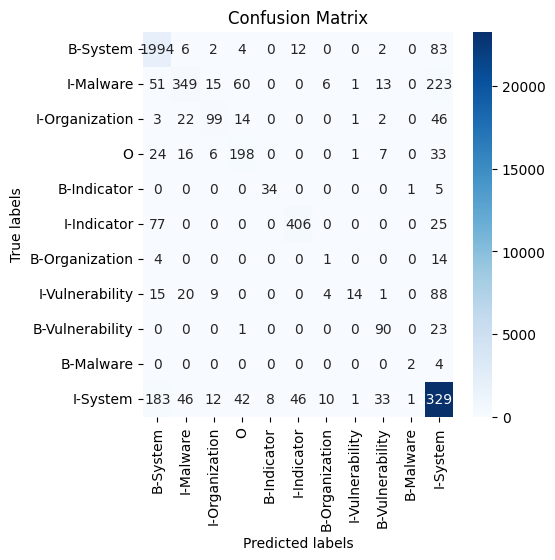

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(labels, predictions)
label_set = set(labels + predictions)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_set, yticklabels=label_set)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
def testing(model, testing_loader):

    model.eval()
    eval_losses=[]
    eval_accuracies=[]
    eval_loss, eval_accuracy = 0, 0
    nb_eval_examples, nb_eval_steps = 0, 0
    eval_preds, eval_labels = [], []

    with torch.no_grad():
        for idx, batch in enumerate(testing_loader):

            ids = batch['ids'].to(device, dtype = torch.long)
            mask = batch['mask'].to(device, dtype = torch.long)
            targets = batch['targets'].to(device, dtype = torch.long)

            outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
            loss, eval_logits = outputs.loss, outputs.logits

            eval_loss += loss.item()

            nb_eval_steps += 1
            nb_eval_examples += targets.size(0)
            loss_step = eval_loss/nb_eval_steps
            if idx % 50==0 and idx!=0:
                print(f"Testing loss per {idx} evaluation steps: {loss_step}")

            eval_losses.append(loss_step)

            flattened_targets = targets.view(-1) # shape (batch_size * seq_len,)
            active_logits = eval_logits.view(-1, model.num_labels) # shape (batch_size * seq_len, num_labels)
            flattened_predictions = torch.argmax(active_logits, axis=1) # shape (batch_size * seq_len,)
            # now, use mask to determine where we should compare predictions with targets (includes [CLS] and [SEP] token predictions)
            active_accuracy = mask.view(-1) == 1 # active accuracy is also of shape (batch_size * seq_len,)
            targets = torch.masked_select(flattened_targets, active_accuracy)
            predictions = torch.masked_select(flattened_predictions, active_accuracy)

            eval_labels.extend(targets)
            eval_preds.extend(predictions)

            tmp_eval_accuracy = accuracy_score(targets.cpu().numpy(), predictions.cpu().numpy())
            eval_accuracies.append(tmp_eval_accuracy)
            eval_accuracy += tmp_eval_accuracy


    labels = [id2label[id.item()] for id in eval_labels]
    predictions = [id2label[id.item()] for id in eval_preds]

    eval_loss = eval_loss / nb_eval_steps
    eval_accuracy = eval_accuracy / nb_eval_steps
    print(f"Testing Loss: {eval_loss}")
    print(f"Testing Accuracy: {eval_accuracy}")

    return labels, predictions,eval_losses,eval_accuracies

In [ ]:
labels, predictions,eval_losses,eval_accuracies = testing(model, testing_loader)

Testing loss per 50 evaluation steps: 0.025231032720637137
Testing loss per 100 evaluation steps: 0.025458919066651188
Testing loss per 150 evaluation steps: 0.02675847659716567
Testing loss per 200 evaluation steps: 0.024331200988247776
Testing loss per 250 evaluation steps: 0.02370395960197419
Testing loss per 300 evaluation steps: 0.02431259047800745
Testing loss per 350 evaluation steps: 0.023491122529641736
Testing Loss: 0.02299972427919842
Testing Accuracy: 0.950609436585436


In [ ]:
from seqeval.metrics import classification_report

print(classification_report([labels], [predictions]))

               precision    recall  f1-score   support

    Indicator       0.82      0.89      0.85      2191
      Malware       0.78      0.66      0.72       626
 Organization       0.57      0.31      0.41       283
       System       0.43      0.49      0.46       417
Vulnerability       0.94      0.80      0.86        40

    micro avg       0.75      0.76      0.75      3557
    macro avg       0.71      0.63      0.66      3557
 weighted avg       0.75      0.76      0.75      3557



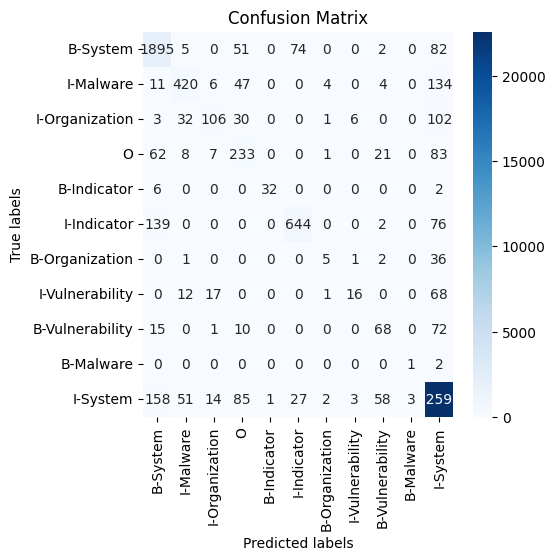

In [ ]:
cm = confusion_matrix(labels, predictions)
label_set = set(labels + predictions)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_set, yticklabels=label_set)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

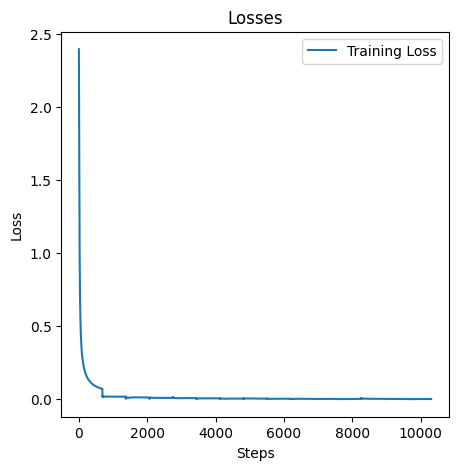

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Losses')
plt.legend()
plt.show()


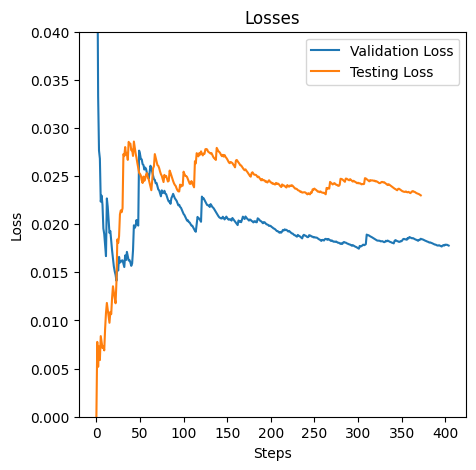

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.plot(val_losses, label='Validation Loss')
plt.plot(eval_losses, label='Testing Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Losses')
plt.ylim(0, 0.04)
plt.legend()

plt.show()

In [ ]:
sentence = "Skygofree : Following in the footsteps of HackingTeam 16 JAN 2018 At the beginning of October 2017 , we discovered new Android spyware with several features previously unseen in the wild ."
inputs = tokenizer(sentence, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors="pt")

# move to gpu
ids = inputs["input_ids"].to(device)
mask = inputs["attention_mask"].to(device)
# forward pass
outputs = model(ids, mask)
logits = outputs[0]

active_logits = logits.view(-1, model.num_labels) # shape (batch_size * seq_len, num_labels)
flattened_predictions = torch.argmax(active_logits, axis=1) # shape (batch_size*seq_len,) - predictions at the token level

tokens = tokenizer.convert_ids_to_tokens(ids.squeeze().tolist())
token_predictions = [id2label[i] for i in flattened_predictions.cpu().numpy()]
wp_preds = list(zip(tokens, token_predictions)) # list of tuples. Each tuple = (wordpiece, prediction)
print(wp_preds)
word_level_predictions = []
for pair in wp_preds:
  if (pair[0].startswith(" ##")) or (pair[0] in ['<s>','<pad>']):
    # skip prediction
    continue
  else:
    word_level_predictions.append(pair[1])

#we join tokens, if they are not special ones
str_rep = " ".join([t[0] for t in wp_preds if t[0] not in ['<s>','<pad>']]).replace(" ##", "")
print(str_rep)
print(word_level_predictions)

[('<s>', 'O'), ('Sky', 'B-Malware'), ('g', 'B-Malware'), ('of', 'B-Malware'), ('ree', 'B-Malware'), ('Ġ:', 'O'), ('ĠFollowing', 'O'), ('Ġin', 'O'), ('Ġthe', 'O'), ('Ġfoot', 'O'), ('steps', 'O'), ('Ġof', 'O'), ('ĠHacking', 'B-Organization'), ('Team', 'O'), ('Ġ16', 'O'), ('ĠJAN', 'O'), ('Ġ2018', 'O'), ('ĠAt', 'O'), ('Ġthe', 'O'), ('Ġbeginning', 'O'), ('Ġof', 'O'), ('ĠOctober', 'O'), ('Ġ2017', 'O'), ('Ġ,', 'O'), ('Ġwe', 'O'), ('Ġdiscovered', 'O'), ('Ġnew', 'O'), ('ĠAndroid', 'B-System'), ('Ġspyware', 'O'), ('Ġwith', 'O'), ('Ġseveral', 'O'), ('Ġfeatures', 'O'), ('Ġpreviously', 'O'), ('Ġunseen', 'O'), ('Ġin', 'O'), ('Ġthe', 'O'), ('Ġwild', 'O'), ('Ġ.', 'O'), ('</s>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<pad>', 'O'), ('<

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/CyberRober_NER.pth")